In [1]:
import pandas as pd
from datetime import date, timedelta
from fiona.crs import from_epsg
import shapely
import math
import random
import geopandas as gpd
import numpy as np

enc = 'utf-8'
dec = 'greek8'
random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
def create_grid(river_shapes, data_shapes, col_municipal='NAME', col_geometry='geometry', dimension=2):
    """Creates the cell grid for the desired area
    
    Parameters
    --------
    river_shapes : dataframe,
        A GeoDataFrame containing the rivers of the area (to avoid creating cells on them)
                
    data_shapes : dataframe
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities
        
    col_municipal : str, optional
        The column that contains the name for each municipality (default = 'NAME')
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    dimension : int, optional
        The dimension of the square cell in km (eg. 2km x 2km, 1km x 1km) (default = 2)
        
    Returns
    ----------
    cell_df: dataframe
        A dataframe containing the generated cells for each municipality and the centers of each cell
    
    """
    river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
    # Convert cell height dimension to km
    cell_height = (dimension / 6378) * (180 / math.pi)
    
    grid_cells = []
    grid_cells2 = []
    municipal = []
    centers = []
    # Iterate over municipalities to create a grid for each one
    for i in range(data_shapes.shape[0]):
        area_cells = []
        center = []
        # Keep the geometry of municipality
        g_country = data_shapes[col_geometry][i]
        # Extract the bounds of municipality
        xmin, ymin, xmax, ymax = data_shapes[col_geometry][i:i+1].total_bounds
        # Convert cell width dimension to km (dependent to y)
        cell_width  = (dimension / 6378) * (180 / math.pi) / math.cos(ymin  * math.pi/180)
    
        # Iterate to municipality bounds to create the grid's cells
        for x0 in np.arange(xmin, xmax+cell_width, cell_width ):
            for y0 in np.arange(ymin, ymax+cell_height, cell_height):
                y1 = y0+cell_height
                x1 = x0+cell_width
                new_cell = shapely.geometry.box(x0, y0, x1, y1)
                # Check if new cell intersects the municipality
                if new_cell.covered_by(g_country):
                    # Check if new cell intersects previously generated cells
                    delete_cell_boundary = [True for cell in grid_cells2 if new_cell.intersects(cell)]
                    # Check if new cell intersects with rivers
                    delete_cell_river = [True for cell in river_shapes_list if new_cell.intersects(cell)]
                    # Save new cell if it doesn't intersects rivers or previous cells 
                    if not delete_cell_boundary and not delete_cell_river:
                        center.append(new_cell.centroid)
                        area_cells.append(new_cell)
                else:
                    # Continue to next cell generation
                    pass
        # Save the final cells for each municipality
        grid_cells.append(area_cells)
        # Save center of each cell
        centers.append(center)
        # Save municipality name for each generated cell
        municipal.append([data_shapes[col_municipal][i]]*len(area_cells))
        # Save the previous generated cells for intersection check
        grid_cells2 = []
        grid_cells2 = [item for sublist in grid_cells for item in sublist]

    # Flatten lists
    grid_cells_list = [item for sublist in grid_cells for item in sublist]
    centers_list = [item for sublist in centers for item in sublist]
    municipal_list = [item for sublist in municipal for item in sublist]
    
    # Create final GeoDataFrame with municipalities and their cells
    cell_df = gpd.GeoDataFrame(grid_cells_list, columns=[col_geometry], crs=from_epsg(4326))
    cell_df['centers'] = centers_list
    cell_df['NAME'] = municipal_list
    
    x = []
    y = []
    # Extract coordinates from centers
    for index,row in cell_df.iterrows():
        x.append(round(row['centers'].x,5))
        y.append(round(row['centers'].y,5))  
        
    cell_df['x'] = x
    cell_df['y'] = y
    
    return cell_df

def read_river_shapes(col_id, path_rivers, col_geometry='geometry', filter=False, num_region=0, path_region='', *args):
    """Reads rivers shapefile and returns a geopandas dataframe
    
    Parameters
    --------
    col_id : string,
        The name of the column with the id of the river
                
    path_rivers : string
        Path to shapefile of rivers
        
    col_geometry : string, optional
        The name of the column with the geometry of the river (default = 'geometry')
        
    filter : boolean, optional
        If false all rivers will be return (default = False)
        
    num_region : int,optional
        The number of the row of the desired region in GeoDataFrame (default = 0)
        
    path_region : string, optional
        Path to shapefile of region that its' rivers will be kept
        
    data_shapes : dataframe, optional (pass with *args)
        A GeoDataFrame containing the polygons (shapes) and the names of municipalities

    Returns
    ----------
    data: dataframe
        A dataframe containing the desired river shapes
    
    """
    try:
        # reading as shp file
        river_shapes = gpd.read_file(path_rivers, encoding="utf_8")
    except: 
        raise NotImplementedError("Sorry, give me a .shp file.")
    if filter:
        indexes = []
        if path_region:
            try:
                # reading as shp file
                region = gpd.read_file(path_region, encoding="utf_8")
            except: 
                raise NotImplementedError("Sorry, give me a .shp file.")
            for index, row in river_shapes.iterrows():
                if row[col_geometry].intersects(region[col_geometry][num_region]):
                    indexes.append(index)
        else:
            data_shapes=args[0]
            for index, row in river_shapes.iterrows():
                for index2, row2 in data_shapes.iterrows():
                    if row[col_geometry].intersects(row2[col_geometry]):
                        indexes.append(index)
                
        river_shapes = river_shapes.loc[indexes].reset_index(drop=True)
    river_shapes = river_shapes[[col_id, col_geometry]]
    return river_shapes

def process_greek(frame, column):
    frame[column] = frame[column].apply(lambda x : x.strip())
    frame[column] = frame[column].apply(lambda x : x.lower())
    frame[column] = frame[column].apply(lambda x : x.replace('ά','α'))
    frame[column] = frame[column].apply(lambda x : x.replace('έ','ε'))
    frame[column] = frame[column].apply(lambda x : x.replace('ή','η'))
    frame[column] = frame[column].apply(lambda x : x.replace('ί','ι'))
    frame[column] = frame[column].apply(lambda x : x.replace('ύ','υ'))
    frame[column] = frame[column].apply(lambda x : x.replace('ό','ο'))
    frame[column] = frame[column].apply(lambda x : x.replace('ώ','ω'))

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"


greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
cmacedonia_region_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ']
cmacedonia_region_gdf.head()

,PER,geometry
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."


In [7]:
indexes = []

region = cmacedonia_region_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

cmacedonia_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
cmacedonia_gdf.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Έδεσσας,9043,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,Αλεξάνδρειας,9023,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,Αλμωπίας,9042,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."


<AxesSubplot:>

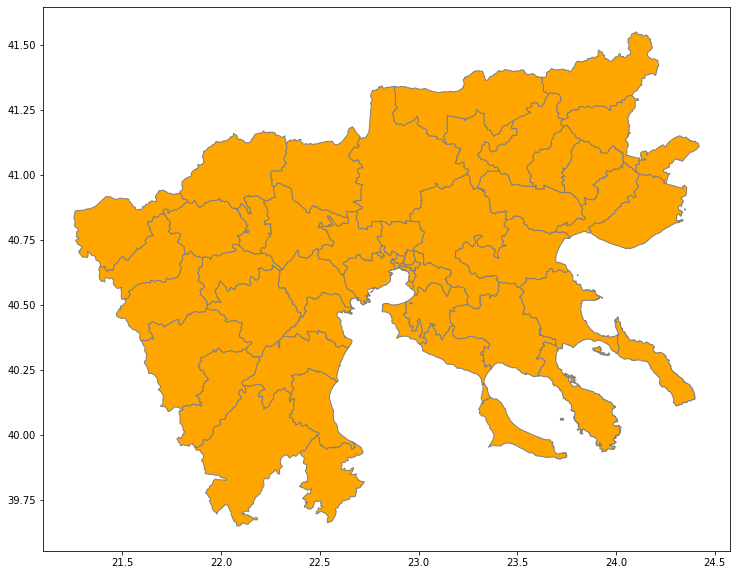

In [9]:
cmacedonia_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
#check QGIS for wrong lau1 units

wrong_list = ['Φλώρινας' ,'Αμυνταίου', 'Εορδαίας', 'Κοζάνης', 'Σερβίων - Βελβεντού', 'Ελασσόνας', 'Τεμπών', 'Κάτω Νευροκοπίου',
 'Προσοτσάνης', 'Δοξάτου', 'Παγγαίου']

cmacedonia_gdf = cmacedonia_gdf[~cmacedonia_gdf['NAME'].isin(wrong_list)].copy()

In [11]:
cmacedonia_gdf.head(5)

,NAME,KWD_YPES,geometry
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Έδεσσας,9043,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,Αλεξάνδρειας,9023,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,Αλμωπίας,9042,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
5,Αμπελοκήπων - Μενεμένης,9026,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


In [12]:
cmacedonia_gdf.drop(columns=['KWD_YPES'], inplace = True)
cmacedonia_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(cmacedonia_gdf, 'lau1')

In [13]:
cmacedonia_gdf.head(5)

,lau1,geometry
1,αθως,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,εδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,αλεξανδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,αλμωπιας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
5,αμπελοκηπων - μενεμενης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


<AxesSubplot:>

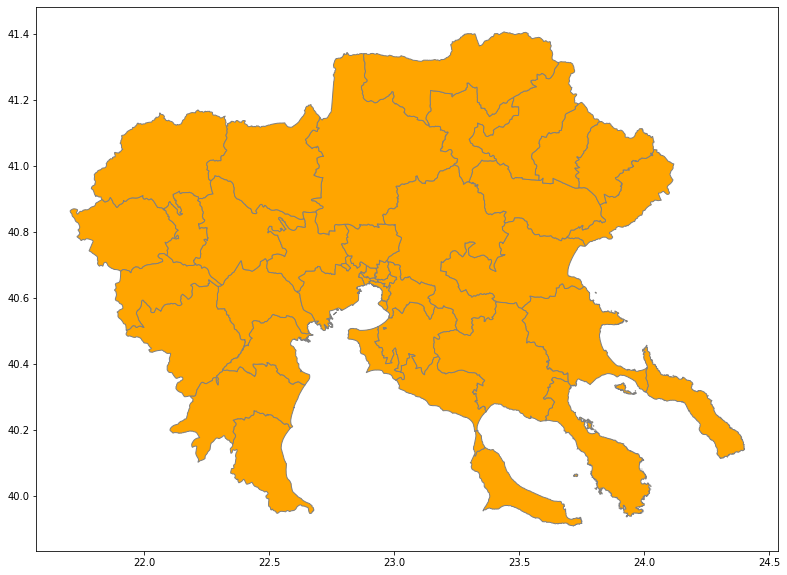

In [14]:
cmacedonia_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
indexes = []

region = cmacedonia_region_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

cmacedonia_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [16]:
cmacedonia_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,21,GR0009000400010100H,None,None,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,yes,17199.809546,"LINESTRING (21.73202 40.68216, 21.79637 40.773..."
1,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
2,227,GR001100040B230320N,ÁÃÉÙÍ ÁÍÁÑÃÕÑÙÍ Ñ.,AGION ANARGYRON S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,7703.516408,"LINESTRING (23.54881 41.12369, 23.54925 41.123..."
3,232,GR0009000400230100N,ÌÁÕÑÏÍÅÑÉ Ð.,MAVRONERI R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,15512.426035,"LINESTRING (22.39929 40.29495, 22.39973 40.294..."
4,233,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,22851.141835,"LINESTRING (23.44204 40.78918, 23.44706 40.789..."


<AxesSubplot:>

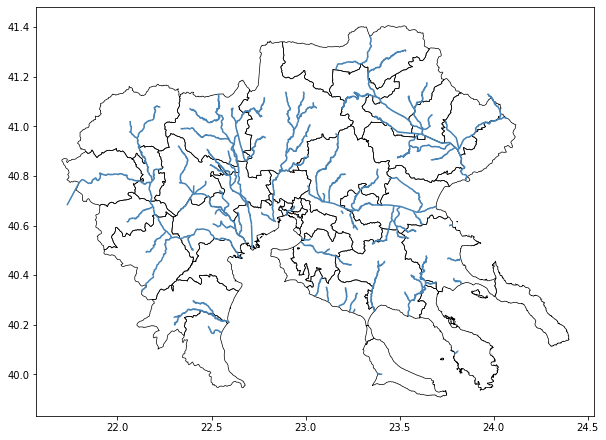

In [17]:
ax = cmacedonia_rivers_gdf.plot(markersize=.1, figsize=(10, 10), cmap='jet', color='steelblue')
cmacedonia_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [18]:
cmacedonia_lau1 = cmacedonia_gdf['lau1'].unique().tolist()

with open('data/GR_SHP_CMacedonia_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in cmacedonia_lau1:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in Central Macedonia (from shapefile): {len(cmacedonia_lau1)}")

Number of LAU1 Units in Central Macedonia (from shapefile): 39


In [19]:
cmacedonia_gdf.reset_index(inplace=True, drop = True)
cmacedonia_rivers_gdf.reset_index(inplace=True, drop=True)

In [20]:
df_grid = create_grid(cmacedonia_rivers_gdf, cmacedonia_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

C:\Users\dimit\AppData\Local\Temp/ipykernel_12628/2153756921.py:27: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert t

In [21]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

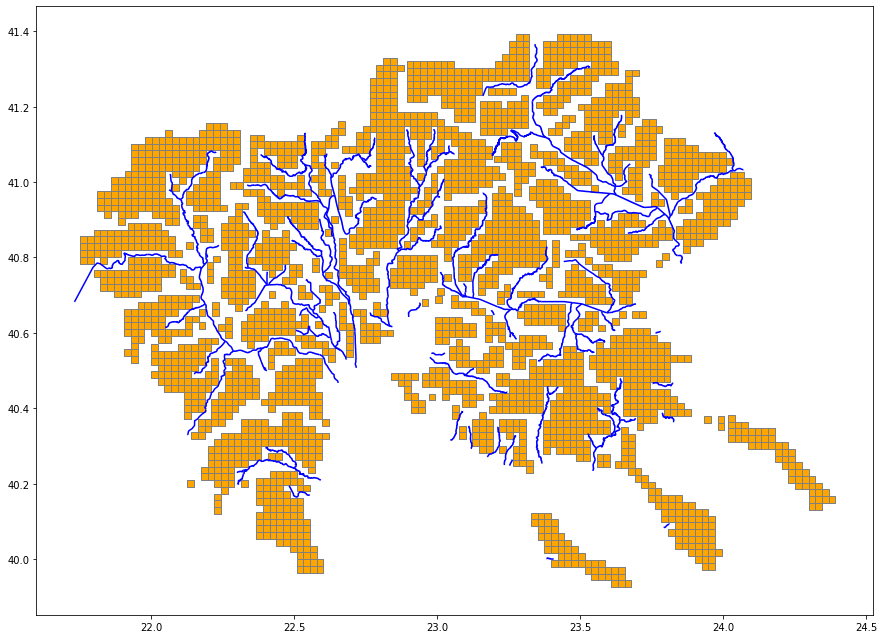

In [22]:
ax = cmacedonia_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [23]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 34


['αμπελοκηπων - μενεμενης', 'θεσσαλονικης', 'καλαμαριας', 'κορδελιου - ευοσμου', 'νεαπολης - συκεων']


C:\Users\dimit\AppData\Local\Temp/ipykernel_12628/1571714933.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


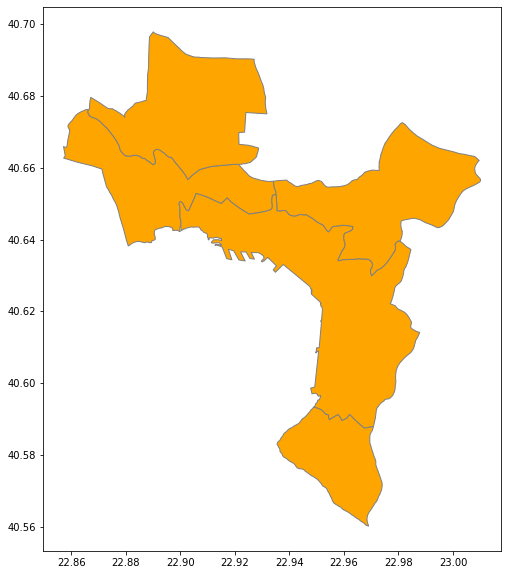

In [24]:
if (len(cmacedonia_lau1) != len(grid_lau1)):
    delta = [item for item in cmacedonia_lau1 if item not in grid_lau1]
    print(delta)

    lost_lau1 = cmacedonia_gdf[cmacedonia_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_cmacedonia_grid = pd.DataFrame()
    add_to_cmacedonia_grid['lau1'] = lost_lau1['lau1']
    add_to_cmacedonia_grid['geometry'] = lost_lau1['geometry']
    add_to_cmacedonia_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_cmacedonia_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [25]:
cmacedonia_grid = df_grid.drop(columns=['centers'])

In [26]:
cmacedonia_grid

,geometry,lau1,x,y
0,"POLYGON ((24.03930 40.31053, 24.03930 40.32849...",αθως,24.02756,40.31951
1,"POLYGON ((24.03930 40.32849, 24.03930 40.34646...",αθως,24.02756,40.33748
2,"POLYGON ((24.03930 40.34646, 24.03930 40.36443...",αθως,24.02756,40.35544
3,"POLYGON ((24.03930 40.36443, 24.03930 40.38240...",αθως,24.02756,40.37341
4,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951
...,...,...,...,...
2765,"POLYGON ((22.97626 40.78967, 22.97626 40.80764...",ωραιοκαστρου,22.96442,40.79866
2766,"POLYGON ((22.99996 40.73577, 22.99996 40.75374...",ωραιοκαστρου,22.98811,40.74476
2767,"POLYGON ((22.99996 40.75374, 22.99996 40.77171...",ωραιοκαστρου,22.98811,40.76272
2768,"POLYGON ((22.99996 40.77171, 22.99996 40.78967...",ωραιοκαστρου,22.98811,40.78069


In [28]:
if (len(cmacedonia_lau1) != len(grid_lau1)):
    cmacedonia_grid = pd.concat([cmacedonia_grid, add_to_cmacedonia_grid], axis=0)

cmacedonia_grid.reset_index(inplace=True, drop=True)

In [29]:
cmacedonia_grid['nuts3'] = 'κεντρικης μακεδονιας'

In [30]:
cmacedonia_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [31]:
cmacedonia_grid

,shape,lau1,x,y,nuts3
0,"POLYGON ((24.03930 40.31053, 24.03930 40.32849...",αθως,24.02756,40.31951,κεντρικης μακεδονιας
1,"POLYGON ((24.03930 40.32849, 24.03930 40.34646...",αθως,24.02756,40.33748,κεντρικης μακεδονιας
2,"POLYGON ((24.03930 40.34646, 24.03930 40.36443...",αθως,24.02756,40.35544,κεντρικης μακεδονιας
3,"POLYGON ((24.03930 40.36443, 24.03930 40.38240...",αθως,24.02756,40.37341,κεντρικης μακεδονιας
4,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951,κεντρικης μακεδονιας
...,...,...,...,...,...
2770,"POLYGON ((22.87764 40.66601, 22.87775 40.66573...",αμπελοκηπων - μενεμενης,22.89198,40.65603,κεντρικης μακεδονιας
2771,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας
2772,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας
2773,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου - ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας


In [32]:
cmacedonia_grid_points = gpd.GeoDataFrame(cmacedonia_grid, geometry=gpd.points_from_xy(cmacedonia_grid.x, cmacedonia_grid.y))

In [33]:
cmacedonia_grid_points

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((24.03930 40.31053, 24.03930 40.32849...",αθως,24.02756,40.31951,κεντρικης μακεδονιας,POINT (24.02756 40.31951)
1,"POLYGON ((24.03930 40.32849, 24.03930 40.34646...",αθως,24.02756,40.33748,κεντρικης μακεδονιας,POINT (24.02756 40.33748)
2,"POLYGON ((24.03930 40.34646, 24.03930 40.36443...",αθως,24.02756,40.35544,κεντρικης μακεδονιας,POINT (24.02756 40.35544)
3,"POLYGON ((24.03930 40.36443, 24.03930 40.38240...",αθως,24.02756,40.37341,κεντρικης μακεδονιας,POINT (24.02756 40.37341)
4,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951,κεντρικης μακεδονιας,POINT (24.05105 40.31951)
...,...,...,...,...,...,...
2770,"POLYGON ((22.87764 40.66601, 22.87775 40.66573...",αμπελοκηπων - μενεμενης,22.89198,40.65603,κεντρικης μακεδονιας,POINT (22.89198 40.65603)
2771,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας,POINT (22.95369 40.62334)
2772,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας,POINT (22.95724 40.57876)
2773,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου - ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας,POINT (22.90326 40.67609)


<AxesSubplot:>

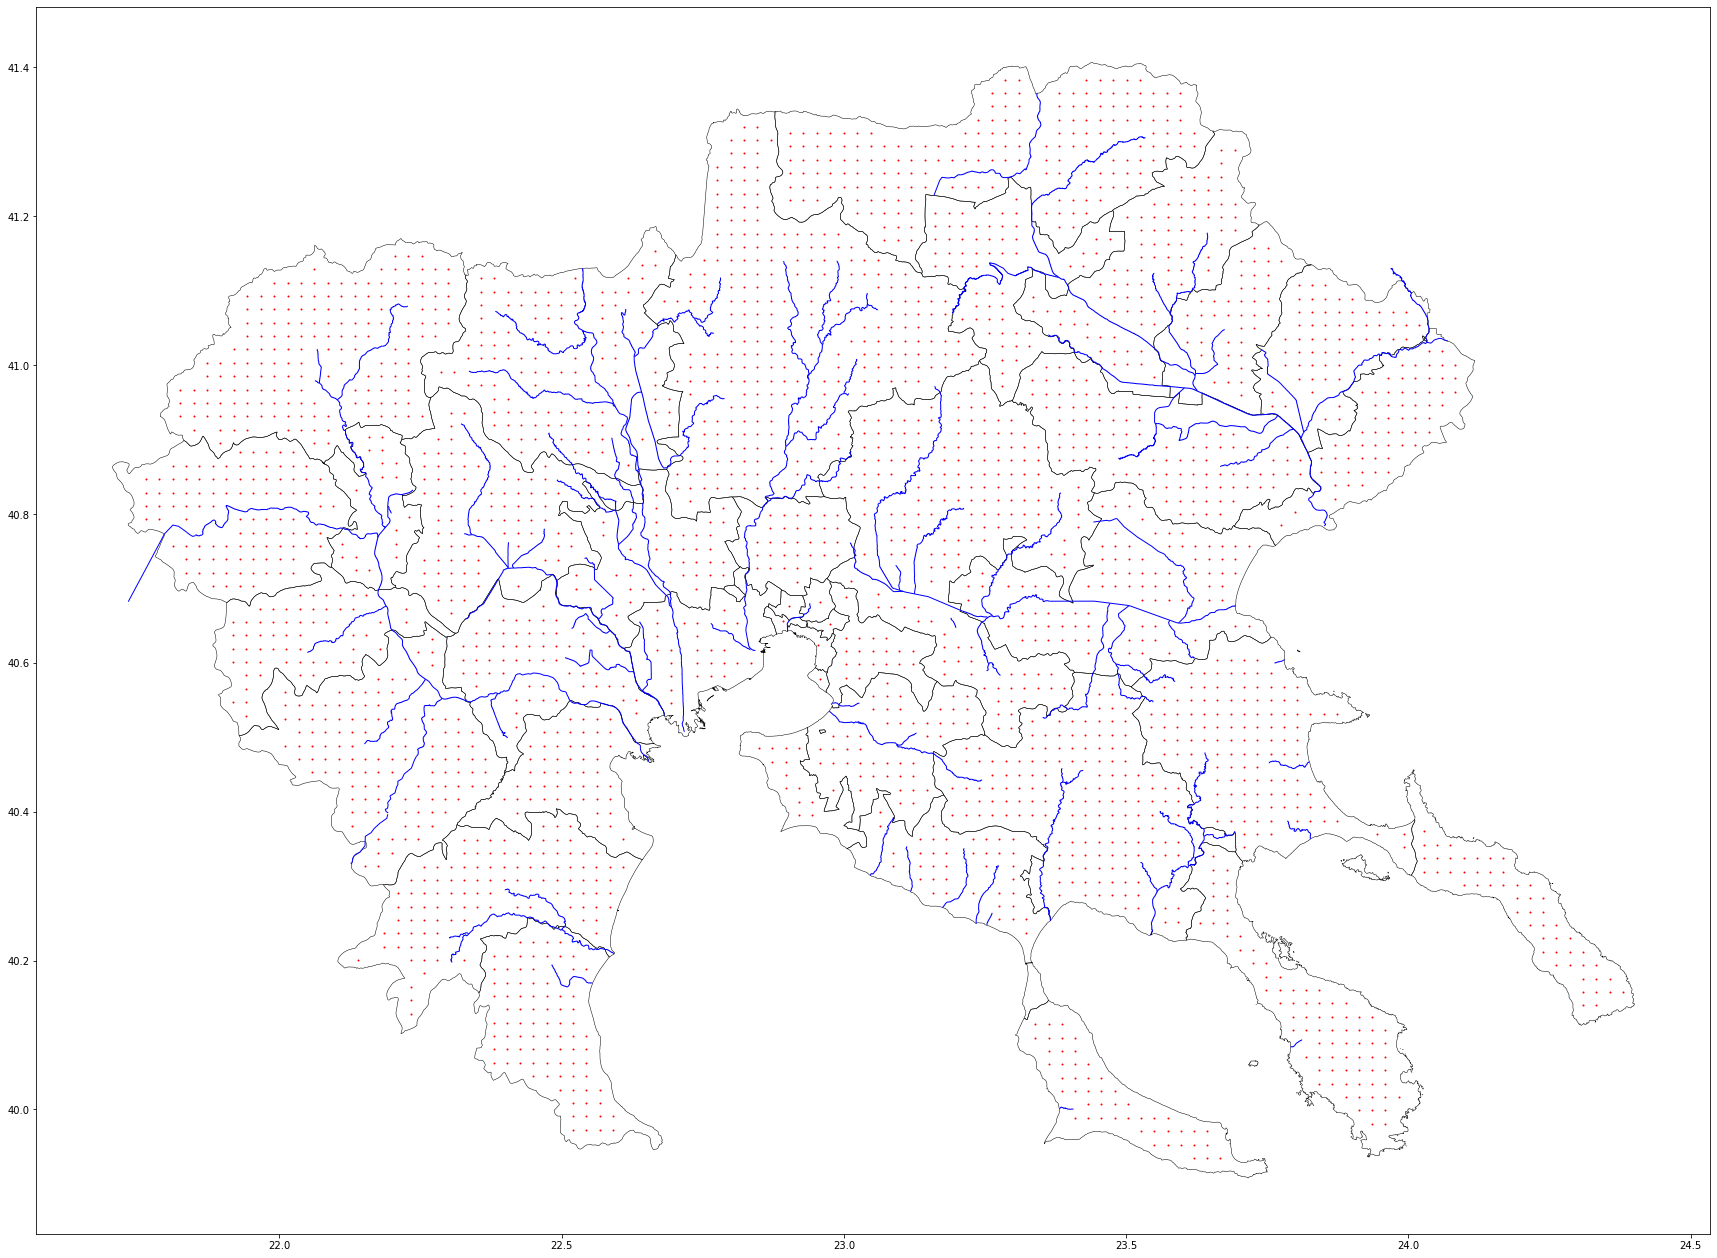

In [34]:
ax = cmacedonia_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
cmacedonia_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
cmacedonia_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [35]:
value_counts = cmacedonia_grid['lau1'].value_counts().sort_values()

In [36]:
arr = value_counts.values

In [37]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [38]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [39]:
value_counts_target

νεαπολης - συκεων           1
παυλου μελα                 1
αμπελοκηπων - μενεμενης     1
κορδελιου - ευοσμου         1
καλαμαριας                  1
θεσσαλονικης                1
θερμαϊκου                   1
σκυδρας                     2
πυλαιας - χορτιατη          2
δελτα                       2
ωραιοκαστρου                2
χαλκηδονος                  3
νεας προποντιδας            3
εμμανουηλ παππα             3
θερμης                      3
κασσανδρας                  3
πυδνας - κολινδρου          4
αθως                        4
ναουσας                     4
αλεξανδρειας                4
νεας ζιχνης                 4
ηρακλειας                   4
αμφιπολης                   4
σιθωνιας                    5
πελλας                      5
σερρων                      5
διου - ολυμπου              6
βολβης                      6
βισαλτιας                   6
εδεσσας                     6
κατερινης                   7
παιονιας                    7
βεροιας                     7
αριστοτελη

In [40]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: θερμαϊκου || Value: 13 || Target Value: 1
Index: σκυδρας || Value: 18 || Target Value: 2
Index: πυλαιας - χορτιατη || Value: 19 || Target Value: 2
Index: δελτα || Value: 26 || Target Value: 2
Index: ωραιοκαστρου || Value: 32 || Target Value: 2
Index: χαλκηδονος || Value: 39 || Target Value: 3
Index: νεας προποντιδας || Value: 39 || Target Value: 3
Index: εμμανουηλ παππα || Value: 42 || Target Value: 3
Index: θερμης || Value: 48 || Target Value: 3
Index: κασσανδρας || Value: 49 || Target Value: 3
Index: πυδνας - κολινδρου || Value: 52 || Target Value: 4
Index: αθως || Value: 53 || Target Value: 4
Index: ναουσας || Value: 58 || Target Value: 4
Index: αλεξανδρειας || Value: 58 || Target Value: 4
Index: νεας ζιχνης || Value: 59 || Target Value: 4
Index: ηρακλειας || Value: 59 || Target Value: 4
Index: αμφιπολης || Value: 63 || Target Value: 4
Index: σιθωνιας || Value: 81 || Target Value: 5
Index: πελλας || Value: 85 || Target Value: 5
Index: σερρων || Value: 85 || Target Value: 5
In

In [41]:
to_remove = pd.Series(data=points, index=idx)

In [42]:
to_remove

θερμαϊκου              12
σκυδρας                16
πυλαιας - χορτιατη     17
δελτα                  24
ωραιοκαστρου           30
χαλκηδονος             36
νεας προποντιδας       36
εμμανουηλ παππα        39
θερμης                 45
κασσανδρας             46
πυδνας - κολινδρου     48
αθως                   49
ναουσας                54
αλεξανδρειας           54
νεας ζιχνης            55
ηρακλειας              55
αμφιπολης              59
σιθωνιας               76
πελλας                 80
σερρων                 80
διου - ολυμπου         80
βολβης                 86
βισαλτιας              93
εδεσσας                95
κατερινης             101
παιονιας              107
βεροιας               110
αριστοτελη            117
πολυγυρου             144
λαγκαδα               165
αλμωπιας              166
σιντικης              175
κιλκις                241
dtype: int64

In [43]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = cmacedonia_grid.loc[cmacedonia_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

cmacedonia_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
cmacedonia_grid.reset_index(inplace = True, drop = True)

In [45]:
cmacedonia_grid_points = gpd.GeoDataFrame(cmacedonia_grid, geometry=gpd.points_from_xy(cmacedonia_grid.x, cmacedonia_grid.y))

<AxesSubplot:>

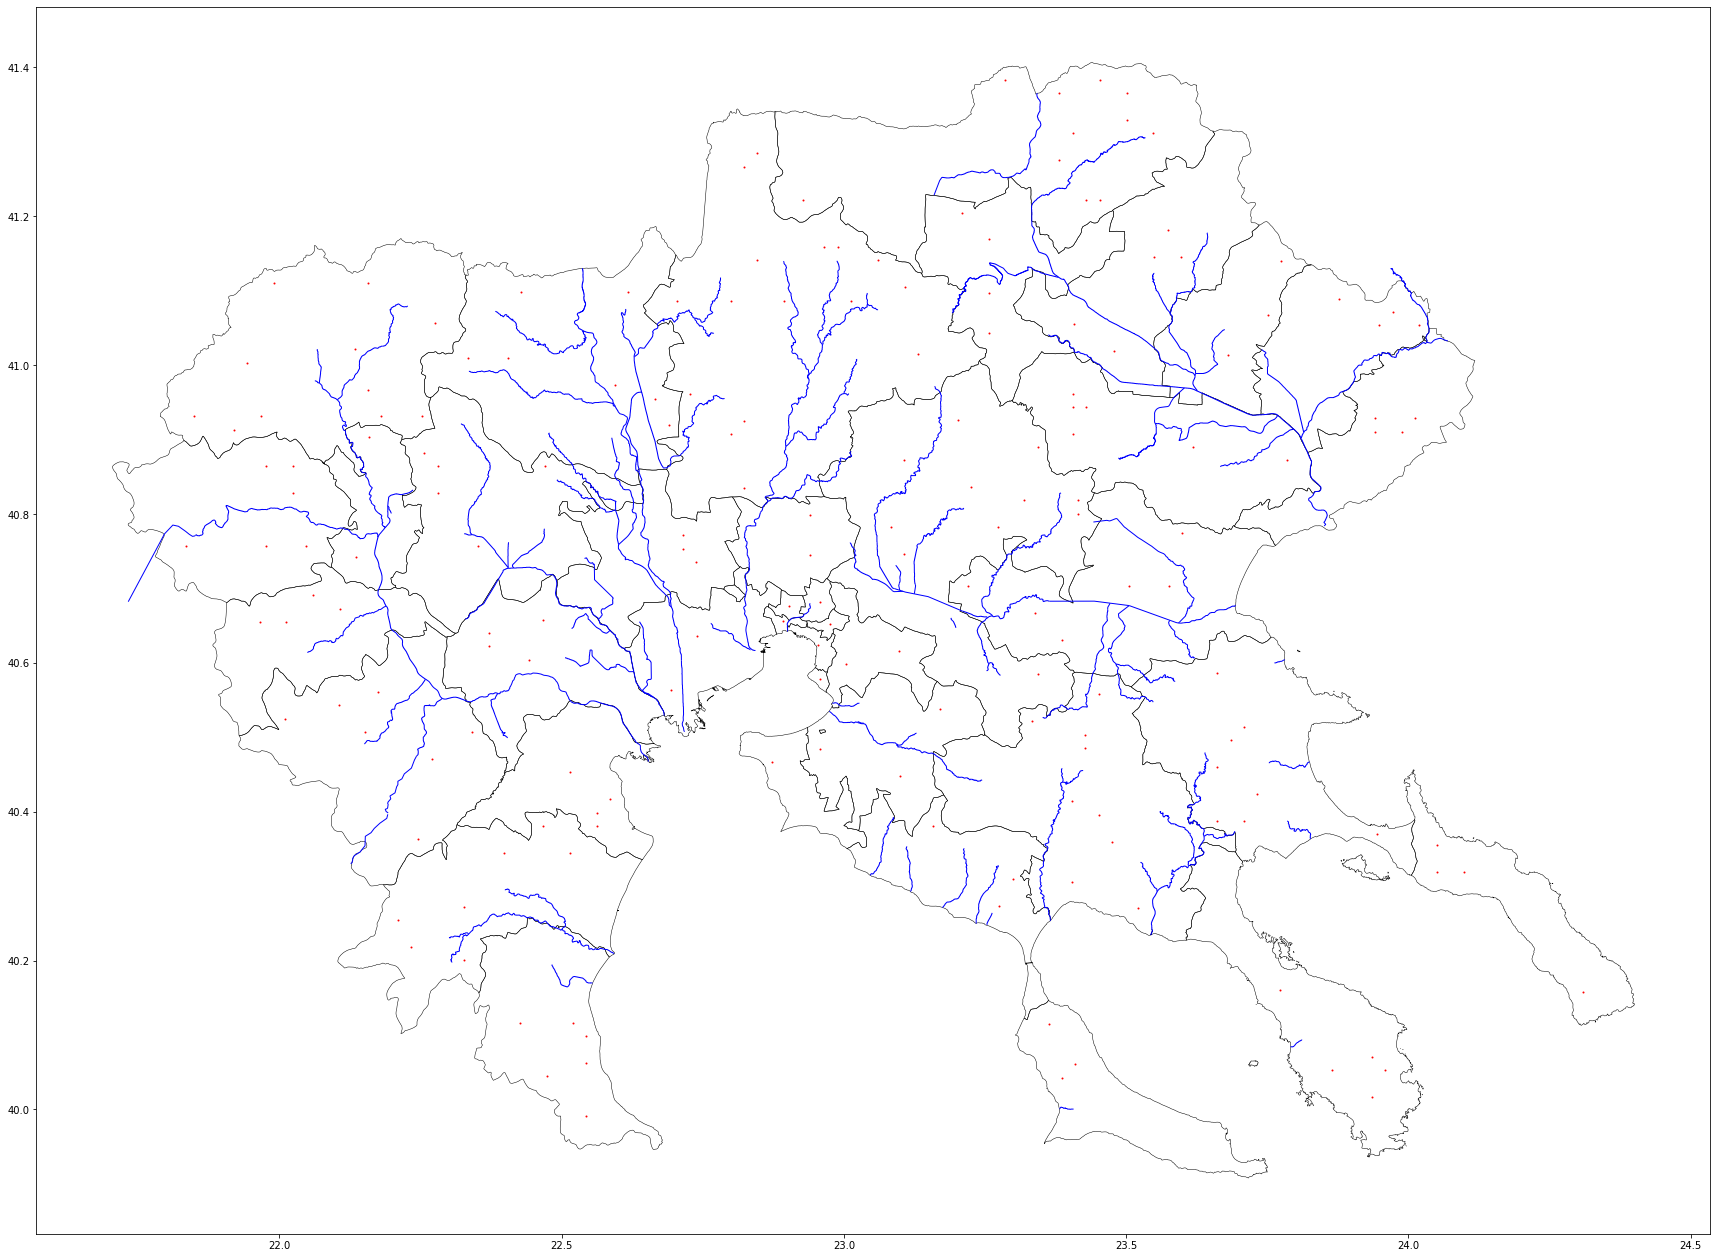

In [46]:
ax = cmacedonia_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
cmacedonia_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
cmacedonia_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [47]:
len(cmacedonia_grid['lau1'].unique())

39

In [48]:
cmacedonia_grid

,shape,lau1,x,y,nuts3,geometry
0,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951,κεντρικης μακεδονιας,POINT (24.05105 40.31951)
1,"POLYGON ((24.06279 40.34646, 24.06279 40.36443...",αθως,24.05105,40.35544,κεντρικης μακεδονιας,POINT (24.05105 40.35544)
2,"POLYGON ((24.10978 40.31053, 24.10978 40.32849...",αθως,24.09803,40.31951,κεντρικης μακεδονιας,POINT (24.09803 40.31951)
3,"POLYGON ((24.32121 40.14883, 24.32121 40.16679...",αθως,24.30947,40.15781,κεντρικης μακεδονιας,POINT (24.30947 40.15781)
4,"POLYGON ((21.84634 40.74801, 21.84634 40.76597...",εδεσσας,21.83449,40.75699,κεντρικης μακεδονιας,POINT (21.83449 40.75699)
...,...,...,...,...,...,...
179,"POLYGON ((22.87764 40.66601, 22.87775 40.66573...",αμπελοκηπων - μενεμενης,22.89198,40.65603,κεντρικης μακεδονιας,POINT (22.89198 40.65603)
180,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας,POINT (22.95369 40.62334)
181,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας,POINT (22.95724 40.57876)
182,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου - ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας,POINT (22.90326 40.67609)


In [49]:
start = start_dt = date(2010, 1, 1)
end = end_dt = date(2021, 12, 31)
delta = timedelta(days=1)

In [50]:
dates = []

while start_dt <= end_dt:
    dates.append(start_dt.isoformat())
    start_dt += delta

In [51]:
print('Dates between', start, 'and', end)
print(dates)

Dates between 2010-01-01 and 2021-12-31
['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08', '2010-01-09', '2010-01-10', '2010-01-11', '2010-01-12', '2010-01-13', '2010-01-14', '2010-01-15', '2010-01-16', '2010-01-17', '2010-01-18', '2010-01-19', '2010-01-20', '2010-01-21', '2010-01-22', '2010-01-23', '2010-01-24', '2010-01-25', '2010-01-26', '2010-01-27', '2010-01-28', '2010-01-29', '2010-01-30', '2010-01-31', '2010-02-01', '2010-02-02', '2010-02-03', '2010-02-04', '2010-02-05', '2010-02-06', '2010-02-07', '2010-02-08', '2010-02-09', '2010-02-10', '2010-02-11', '2010-02-12', '2010-02-13', '2010-02-14', '2010-02-15', '2010-02-16', '2010-02-17', '2010-02-18', '2010-02-19', '2010-02-20', '2010-02-21', '2010-02-22', '2010-02-23', '2010-02-24', '2010-02-25', '2010-02-26', '2010-02-27', '2010-02-28', '2010-03-01', '2010-03-02', '2010-03-03', '2010-03-04', '2010-03-05', '2010-03-06', '2010-03-07', '2010-03-08', '2010-03-09', '2010-0

In [52]:
len(dates)

4383

In [54]:
cmacedonia_timeline = pd.DataFrame()

In [55]:
for index, row in cmacedonia_grid.iterrows():
    for date in dates:
        cmacedonia_timeline = cmacedonia_timeline.append({'lau1' : row['lau1'], 
                                                  'region' : row['nuts3'], 
                                                  'x' : row['x'],
                                                  'y' : row['y'],
                                                  'dt_placement': date}, 
                                                  ignore_index = True)

In [56]:
cmacedonia_timeline

,lau1,region,x,y,dt_placement
0,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-01
1,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-02
2,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-03
3,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-04
4,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-05
...,...,...,...,...,...
806467,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-27
806468,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-28
806469,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-29
806470,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-30


In [57]:
cmacedonia_timeline['dt_placement'] = pd.to_datetime(cmacedonia_timeline['dt_placement'])

In [58]:
cmacedonia_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806472 entries, 0 to 806471
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   lau1          806472 non-null  object        
 1   region        806472 non-null  object        
 2   x             806472 non-null  float64       
 3   y             806472 non-null  float64       
 4   dt_placement  806472 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 30.8+ MB


In [59]:
cmacedonia_timeline.to_csv('data/GR_CMacedonia_Spatiotemporal_Timeline_2010-2021.csv', index = False)

In [60]:
cmacedonia_timeline

,lau1,region,x,y,dt_placement
0,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-01
1,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-02
2,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-03
3,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-04
4,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-05
...,...,...,...,...,...
806467,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-27
806468,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-28
806469,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-29
806470,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-30


In [61]:
cmacedonia_timeline['dt_placement'].iloc[15].day

16

In [62]:
cmacedonia_timeline_biweekly = cmacedonia_timeline.copy()
remove = []

for index, row in cmacedonia_timeline.iterrows():
    if row['dt_placement'].day == 1 or row['dt_placement'].day == 16:
        pass
    else:
        remove.append(index)


cmacedonia_timeline_biweekly.drop(index = remove, axis = 1, inplace = True)
cmacedonia_timeline_biweekly.reset_index(inplace = True, drop = True)

In [63]:
cmacedonia_timeline_biweekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52992 entries, 0 to 52991
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   lau1          52992 non-null  object        
 1   region        52992 non-null  object        
 2   x             52992 non-null  float64       
 3   y             52992 non-null  float64       
 4   dt_placement  52992 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 2.0+ MB


In [64]:
cmacedonia_timeline_biweekly.to_csv('data/GR_CMacedonia_Spatiotemporal_Timeline_Biweekly_2010-2021.csv', index = False)